IPL Match Data Analyzer"
Problem Statement:
You have a CSV of all IPL matches from 2008–2023. A cricket board wants insights: which team wins most at home, which venue has highest scores, which season had most super overs. Answer these with Pandas and visualize with Matplotlib/Seaborn.
Stack: Python, Pandas, Matplotlib, Seaborn
Input: IPL CSV dataset (Kaggle)
Output: Bar charts, heatmaps, pivot tables with insights
Think about:
How do you handle missing values in match data?
What's the difference between groupby and pivot_table?
How do you filter rows based on multiple conditions?
Which visualization best shows win percentage — bar or pie?

In [6]:
#step 1 import libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
##step 2 csv file
df = pd.read_csv("Cricket_data.csv")

print(df.head())

   season       id                                          name short_name  \
0     NaN  1370350          Chennai Super Kings v Gujarat Titans   CSK v GT   
1     NaN  1370351         Lucknow Super Giants v Mumbai Indians   LSG v MI   
2     NaN  1370352                                     TBC v TBC  TBC v TBC   
3     NaN  1370353                                     TBC v TBC  TBC v TBC   
4  2023.0  1359544  Royal Challengers Bangalore v Gujarat Titans   RCB v GT   

                                         description home_team away_team  \
0  Qualifier 1 (N), Indian Premier League at Chen...       CSK        GT   
1  Eliminator (N), Indian Premier League at Chenn...       LSG        MI   
2  Qualifier 2 (N), Indian Premier League at Ahme...       TBA       TBA   
3  Final (N), Indian Premier League at Ahmedabad,...       TBA       TBA   
4  70th Match (N), Indian Premier League at Benga...       RCB        GT   

  toss_won    decision 1st_inning_score  ...  \
0      NaN         N

In [10]:
#step 3 columns check
print(df.columns)


Index(['season', 'id', 'name', 'short_name', 'description', 'home_team',
       'away_team', 'toss_won', 'decision', '1st_inning_score',
       '2nd_inning_score', 'winner', 'result', 'start_date', 'end_date',
       'venue_id', 'venue_name', 'home_captain', 'away_captain', 'pom',
       'points', 'super_over', 'home_overs', 'home_runs', 'home_wickets',
       'home_boundaries', 'away_overs', 'away_runs', 'away_wickets',
       'away_boundaries', 'highlights', 'home_key_batsman', 'home_key_bowler',
       'home_playx1', 'away_playx1', 'away_key_batsman', 'away_key_bowler',
       'match_days', 'umpire1', 'umpire2', 'tv_umpire', 'referee',
       'reserve_umpire'],
      dtype='object')


In [11]:
##Step 2: Data Cleaning
# Remove rows where season is missing
df = df.dropna(subset=['season'])

# Fill missing super_over
df['super_over'] = df['super_over'].fillna('No')

# Convert season to int
df['season'] = df['season'].astype(int)

# Create total_runs column (VERY IMPORTANT FIX)
df['total_runs'] = df['home_runs'].fillna(0) + df['away_runs'].fillna(0)

print(df.isnull().sum())

season               0
id                   0
name                 0
short_name           0
description          0
home_team            0
away_team            0
toss_won             0
decision             0
1st_inning_score     8
2nd_inning_score    10
winner               1
result               0
start_date           0
end_date             0
venue_id             0
venue_name           0
home_captain         0
away_captain         0
pom                 12
points              60
super_over           0
home_overs           8
home_runs            8
home_wickets         8
home_boundaries      8
away_overs          10
away_runs           10
away_wickets        10
away_boundaries     10
highlights          22
home_key_batsman     8
home_key_bowler     21
home_playx1          0
away_playx1          0
away_key_batsman    10
away_key_bowler     19
match_days           0
umpire1              0
umpire2              0
tv_umpire            2
referee              0
reserve_umpire      26
total_runs 

C:\Users\Admin\AppData\Local\Temp\ipykernel_328\2459963624.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['super_over'] = df['super_over'].fillna('No')


home_team
CSK      79
MI       70
KKR      64
RCB      61
DC       60
SRH      56
RR       56
KXIP     47
GT       11
LSG       7
RPS       7
PWI       6
PBKS      5
GL        5
Kochi     3
Name: count, dtype: int64


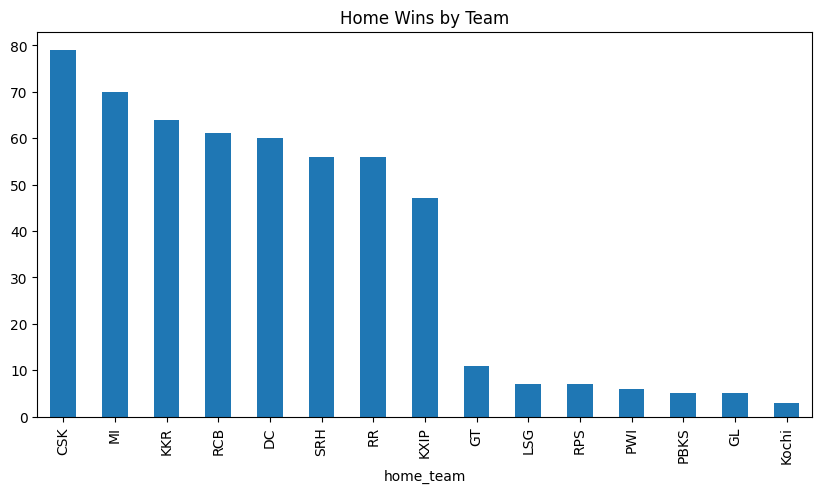

In [12]:
##Step 3: Most Home Wins
home_wins = df[df['winner'] == df['home_team']]
home_win_count = home_wins['home_team'].value_counts()

print(home_win_count)

# Plot
home_win_count.plot(kind='bar', figsize=(10,5))
plt.title("Home Wins by Team")
plt.show()

venue_name
Barsapara Cricket Stadium, Guwahati                         365.000000
Brabourne Stadium, Mumbai                                   344.629630
Himachal Pradesh Cricket Association Stadium, Dharamsala    334.909091
Saurashtra Cricket Association Stadium, Rajkot              331.600000
Narendra Modi Stadium, Motera, Ahmedabad                    329.928571
Name: total_runs, dtype: float64


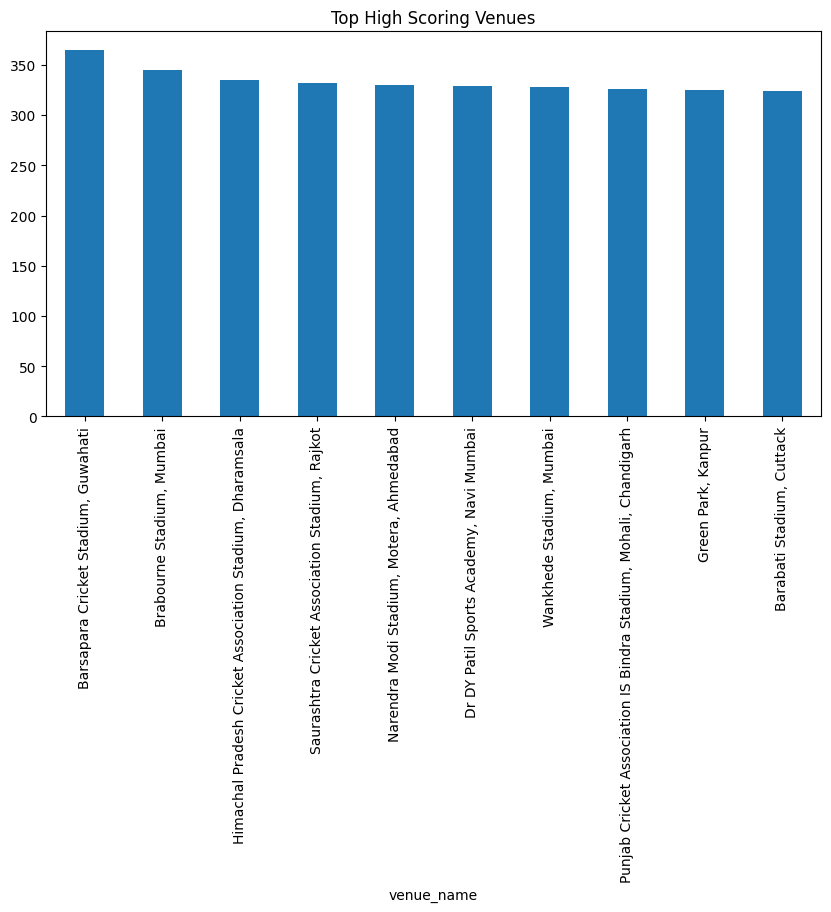

In [50]:
##Step 4: Highest Scoring Venue
venue_runs = df.groupby('venue_name')['total_runs'].mean().sort_values(ascending=False)

print(venue_runs.head())

venue_runs.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top High Scoring Venues")
plt.show()

Super over unique values: [False  True]
season
2013    2
2014    1
2015    1
2017    1
2019    2
2020    4
2021    1
dtype: int64


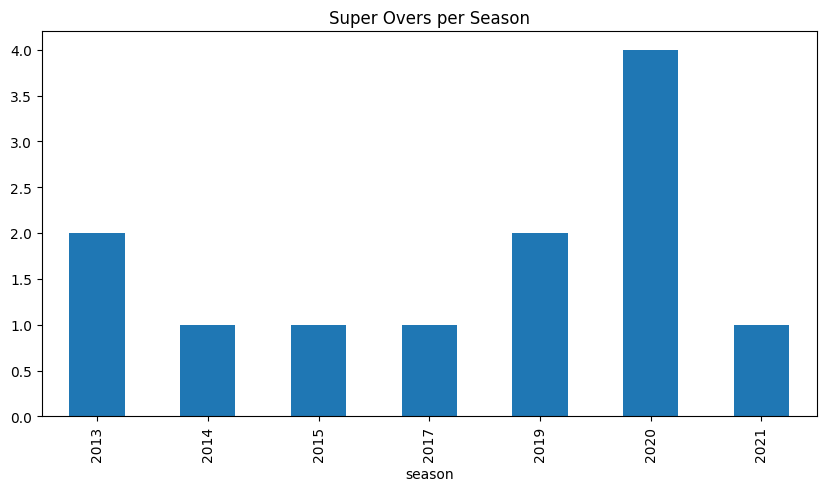

In [13]:
##Step 5: Season with Most Super Overs
# Check what values exist in super_over column
print("Super over unique values:", df['super_over'].unique())

# Filter for super overs (handle case-insensitive and various formats)
super_overs = df[df['super_over'].astype(str).str.lower().isin(['yes', 'true', '1'])]
super_over_count = super_overs.groupby('season').size()

print(super_over_count)

if len(super_over_count) > 0:
    super_over_count.plot(kind='bar', figsize=(10,5))
    plt.title("Super Overs per Season")
    plt.show()
else:
    print("No super overs found in data")

Top 10 venues by max match total (using 'venue_name'):
venue_name
MA Chidambaram Stadium, Chepauk, Chennai                            469.0
Holkar Cricket Stadium, Indore                                      459.0
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh    458.0
Wankhede Stadium, Mumbai                                            453.0
Sharjah Cricket Stadium                                             449.0
M.Chinnaswamy Stadium, Bengaluru                                    444.0
Arun Jaitley Stadium, Delhi                                         437.0
Eden Gardens, Kolkata                                               433.0
Rajiv Gandhi International Stadium, Uppal, Hyderabad                431.0
Sawai Mansingh Stadium, Jaipur                                      431.0
Name: total_runs, dtype: float64


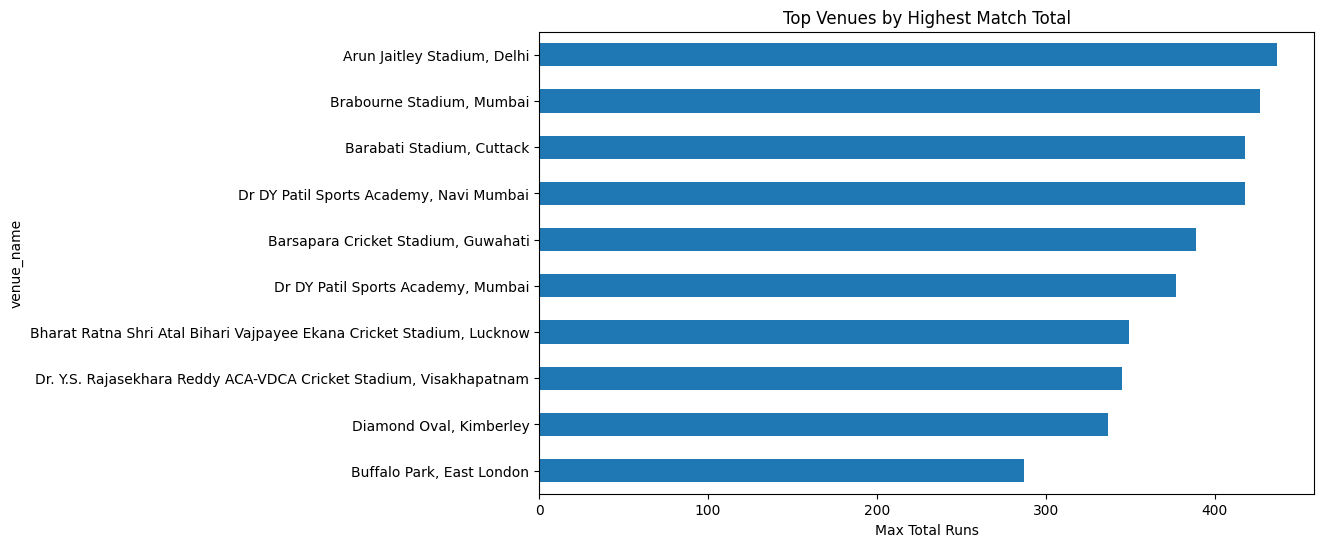

In [14]:
##STEP 8: Highest score venue
# Check which venue column exists
venue_col = 'venue_name' if 'venue_name' in df.columns else 'venue' if 'venue' in df.columns else None

if venue_col and 'total_runs' in df.columns:
    venue_score = df.groupby(venue_col)['total_runs'].max()
    print(f"Top 10 venues by max match total (using '{venue_col}'):")
    print(venue_score.sort_values(ascending=False).head(10))
    
    if len(venue_score) > 0:
        venue_score.head(10).sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
        plt.title("Top Venues by Highest Match Total")
        plt.xlabel("Max Total Runs")
        plt.show()
else:
    print("Required columns not found. Available columns:", df.columns.tolist())

In [15]:
pd.pivot_table(df, values='id', index='home_team', columns='season', aggfunc='count')

season,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
home_team,,,,,,,,,,,,,,,,
CSK,9.0,13.0,8.0,9.0,11.0,10.0,8.0,10.0,NaN,NaN,8.0,8.0,7.0,8.0,7.0,7.0
DC,8.0,8.0,7.0,7.0,9.0,8.0,7.0,7.0,7.0,7.0,7.0,8.0,10.0,9.0,7.0,7.0
GL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN
GT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,7.0
KKR,7.0,4.0,7.0,7.0,8.0,8.0,8.0,7.0,8.0,7.0,9.0,7.0,7.0,7.0,7.0,7.0
KXIP,7.0,6.0,7.0,7.0,8.0,8.0,8.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN
Kochi,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,6.0
MI,7.0,2.0,9.0,9.0,8.0,9.0,8.0,7.0,7.0,10.0,7.0,9.0,7.0,7.0,7.0,7.0


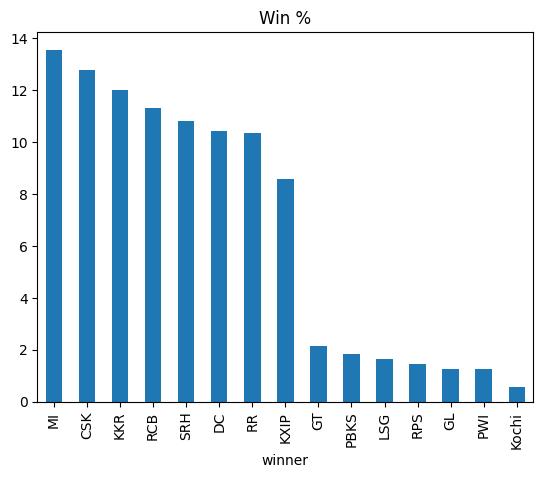

In [16]:
##STEP 12: Win percentage
win = df['winner'].value_counts()

(win / win.sum() * 100).plot(kind='bar')
plt.title("Win %")
plt.show()

In [34]:
pd.pivot_table(df, values='id', index=team1, columns='season', aggfunc='count')

season,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
id,59,59,60,74,76,76,60,60,60,60,60,60,60,60,74,69


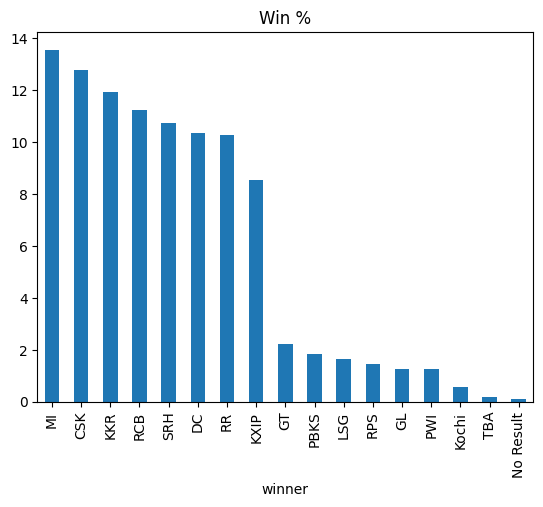

In [36]:
##STEP 12: Win percentage
win = df['winner'].value_counts()

(win / win.sum() * 100).plot(kind='bar')
plt.title("Win %")
plt.show()

In [17]:
##Step 6: Pivot Table
pivot = pd.pivot_table(df, values='total_runs',
                       index='season',
                       columns='winner',
                       aggfunc='mean')

print(pivot)

winner         CSK          DC     GL          GT         KKR        KXIP  \
season                                                                      
2008    327.222222  327.285714    NaN         NaN  250.857143  317.900000   
2009    286.000000  286.200000    NaN         NaN  223.400000  283.000000   
2010    324.700000  299.857143    NaN         NaN  304.000000  313.000000   
2011    314.636364  361.000000    NaN         NaN  256.250000  332.428571   
2012    285.181818  261.166667    NaN         NaN  287.166667  299.000000   
2013    319.583333  304.000000    NaN         NaN  270.333333  313.250000   
2014    300.600000  292.000000    NaN         NaN  313.833333  344.333333   
2015    304.900000  296.600000    NaN         NaN  324.857143  302.666667   
2016           NaN  312.000000  328.0         NaN  283.750000  298.500000   
2017           NaN  359.166667  342.0         NaN  303.555556  305.714286   
2018    348.181818  348.200000    NaN         NaN  346.333333  333.333333   

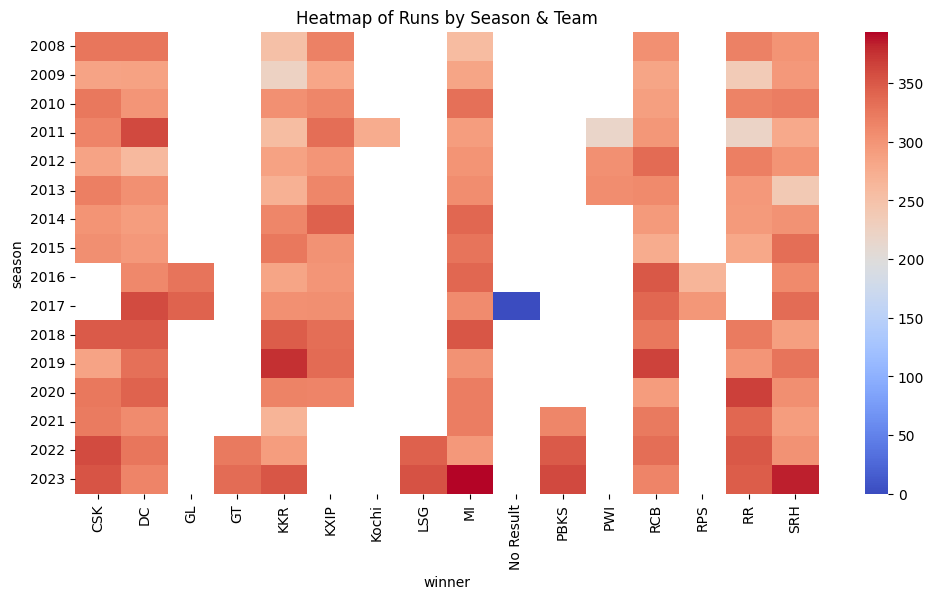

In [49]:
##Step 7: Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap of Runs by Season & Team")
plt.show()